In [8]:
import os 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf 
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

#### configuração visual

In [9]:
plt.rcParams.update({"figure.dpi": 130, 'axes.spines.top': False, 'axes.spines.right':False})

print('TensorFlow: ', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPU disponível:" if gpus else "Rodando em CPU (sem GPU detectada)")
for g in gpus:
    print(" →", g)

TensorFlow:  2.21.0
Rodando em CPU (sem GPU detectada)


#### configurações globais

In [10]:
# ajuste este caminho para onde seu esta seu dataset pré-processado
BASE_DIR = r"C:\Users\vitor\Documents\GitHub\Cap-1---Visao-Computacional-na-Clinica\pre-processamento\dataset_processado" 

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "val")
TEST_DIR  = os.path.join(BASE_DIR, "test")

IMG_SIZE    = (224, 224)   # VGG16 e ResNet50 esperam 224x224
BATCH_SIZE  = 32
EPOCHS_CNN  = 20
EPOCHS_TL   = 20
NUM_CLASSES = 2            # Normal, Pneumonia
CLASS_NAMES = ["Normal", "Pneumonia"]

# Pasta para salvar modelos e figuras (cria se não existir)
OUTPUT_DIR = os.path.join(BASE_DIR, "resultados")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Train : {TRAIN_DIR}")
print(f"Val   : {VAL_DIR}")
print(f"Test  : {TEST_DIR}")
print(f"Output: {OUTPUT_DIR}")

Train : C:\Users\vitor\Documents\GitHub\Cap-1---Visao-Computacional-na-Clinica\pre-processamento\dataset_processado\train
Val   : C:\Users\vitor\Documents\GitHub\Cap-1---Visao-Computacional-na-Clinica\pre-processamento\dataset_processado\val
Test  : C:\Users\vitor\Documents\GitHub\Cap-1---Visao-Computacional-na-Clinica\pre-processamento\dataset_processado\test
Output: C:\Users\vitor\Documents\GitHub\Cap-1---Visao-Computacional-na-Clinica\pre-processamento\dataset_processado\resultados


#### Gerador de dados


In [11]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest",
)

# Validação e teste: apenas normalização, SEM augmentation
val_test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True,
    seed=42,
)

val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False,
)

test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False,
)

print("\nClasses detectadas:", train_gen.class_indices)
print(f"Treino : {train_gen.samples} imagens")
print(f"Val    : {val_gen.samples} imagens")
print(f"Teste  : {test_gen.samples} imagens")

Found 4099 images belonging to 2 classes.
Found 878 images belonging to 2 classes.
Found 879 images belonging to 2 classes.

Classes detectadas: {'NORMAL': 0, 'PNEUMONIA': 1}
Treino : 4099 imagens
Val    : 878 imagens
Teste  : 879 imagens


#### Visualização de amostras do dataset

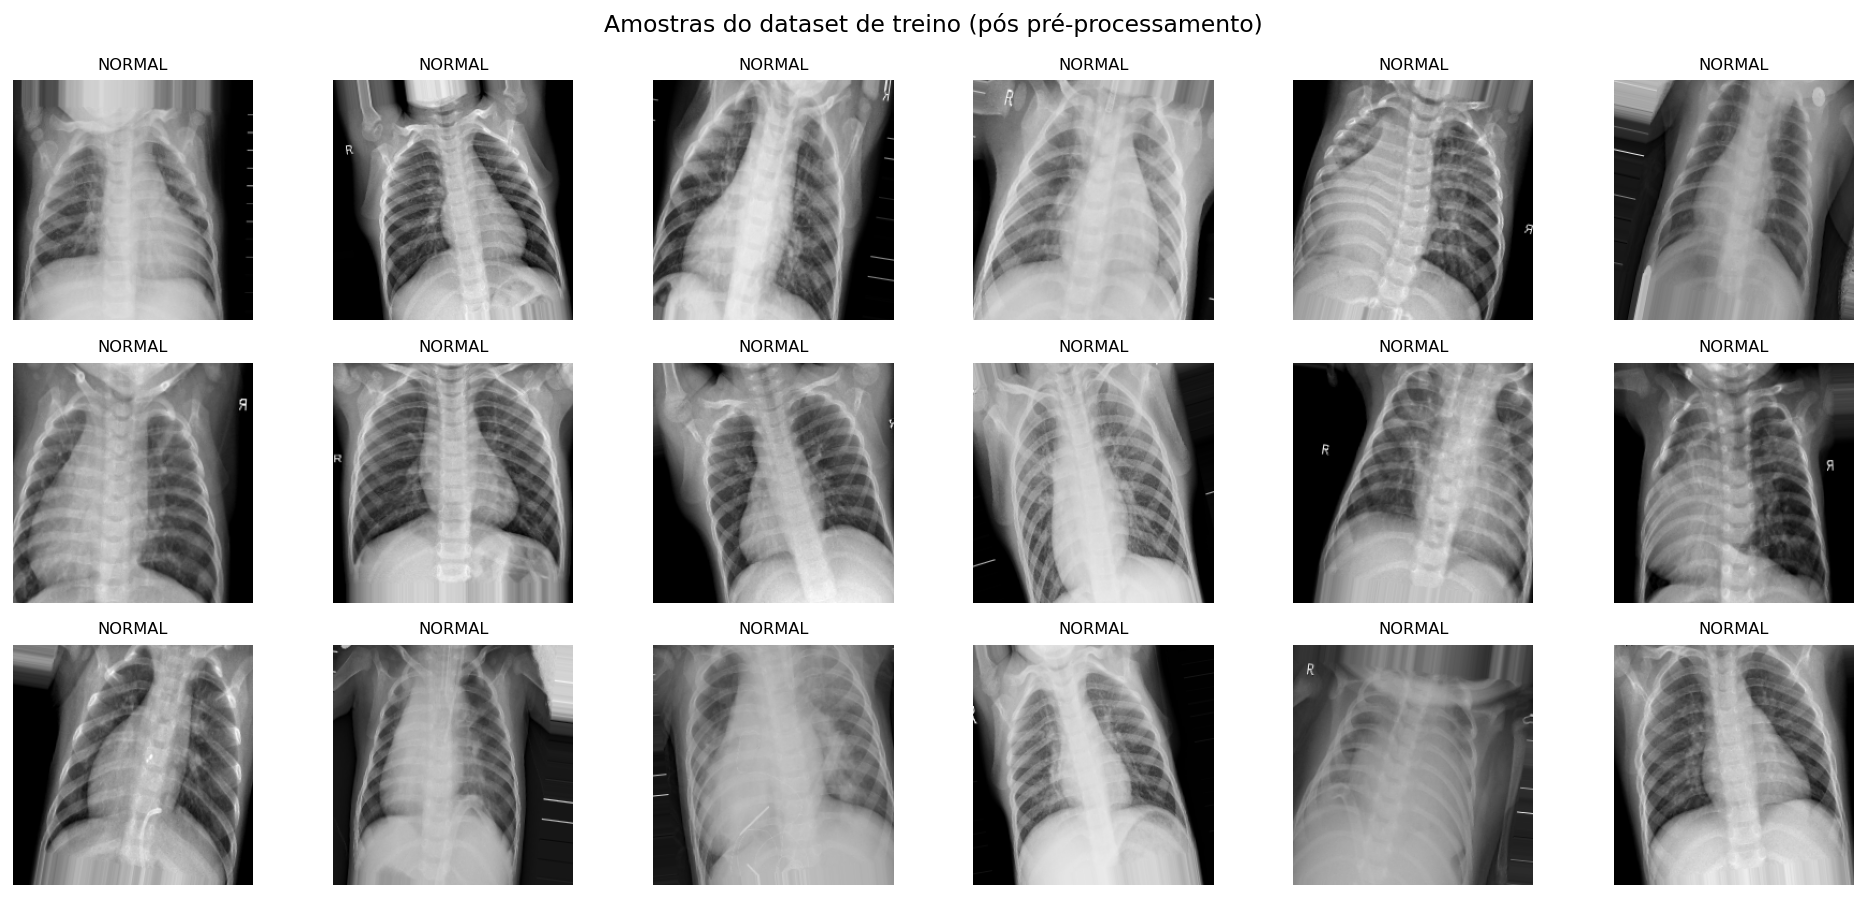

In [12]:
imgs, labels = next(train_gen)
fig, axes = plt.subplots(3, 6, figsize=(15, 7))
fig.suptitle("Amostras do dataset de treino (pós pré-processamento)", fontsize=13)

label_to_name = {v: k for k, v in train_gen.class_indices.items()}

for i, ax in enumerate(axes.flat):
    if i < len(imgs):
        ax.imshow(imgs[i])
        ax.set_title(label_to_name[np.argmax(labels[i])], fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "00_amostras_dataset.png"), bbox_inches="tight")
plt.show()

#### callback

In [13]:
def make_callbacks(model_name):
    return [
        EarlyStopping(
            monitor="val_accuracy",
            patience=5,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1,
        ),
        ModelCheckpoint(
            filepath=os.path.join(OUTPUT_DIR, f"melhor_{model_name}.keras"),
            monitor="val_accuracy",
            save_best_only=True,
            verbose=1,
        ),
    ]


#### abordagem 1: CNN simples

In [16]:
def build_cnn_simples(num_classes=3, input_shape=(224, 224, 3)):
    """
    CNN com 3 blocos convolucionais treinada do zero.
    Cada bloco: Conv2D → BatchNorm → Conv2D → MaxPool → Dropout
    """
    model = keras.Sequential(name="CNN_Simples")

    # Bloco 1 – 32 filtros
    model.add(layers.Conv2D(32, (3, 3), activation="relu", padding="same",
                             input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3, 3), activation="relu", padding="same"))
    model.add(layers.MaxPooling2D(2, 2))
    model.add(layers.Dropout(0.25))

    # Bloco 2 – 64 filtros
    model.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same"))
    model.add(layers.MaxPooling2D(2, 2))
    model.add(layers.Dropout(0.25))

    # Bloco 3 – 128 filtros
    model.add(layers.Conv2D(128, (3, 3), activation="relu", padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3, 3), activation="relu", padding="same"))
    model.add(layers.MaxPooling2D(2, 2))
    model.add(layers.Dropout(0.4))

    # Classificador
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(256, activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(1, activation="sigmoid"))

    return model


model_cnn = build_cnn_simples(num_classes=NUM_CLASSES)
model_cnn.summary()

model_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

print("\n▶ Treinando CNN simples...")
history_cnn = model_cnn.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_CNN,
    callbacks=make_callbacks("cnn_simples"),
)
print("✓ CNN simples treinada.")

Model: "CNN_Simples"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,209 (1.23 MB)

 Trainable params: 321,249 (1.23 MB)

 Non-trainable params: 960 (3.75 KB)


▶ Treinando CNN simples...
Epoch 1/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7633 - loss: 0.5307
Epoch 1: val_accuracy improved from None to 0.73007, saving model to C:\Users\vitor\Documents\GitHub\Cap-1---Visao-Computacional-na-Clinica\pre-processamento\dataset_processado\resultados\melhor_cnn_simples.keras
129/129 ━━━━━━━━━━━━━━━━━━━━ 269s 2s/step - accuracy: 0.8185 - loss: 0.4251 - val_accuracy: 0.7301 - val_loss: 1.1120 - learning_rate: 0.0010
Epoch 2/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8815 - loss: 0.2886
Epoch 2: val_accuracy did not improve from 0.73007
129/129 ━━━━━━━━━━━━━━━━━━━━ 257s 2s/step - accuracy: 0.8807 - loss: 0.2974 - val_accuracy: 0.7301 - val_loss: 1.9080 - learning_rate: 0.0010
Epoch 3/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8961 - loss: 0.2631
Epoch 3: val_accuracy did not improve from 0.73007
129/129 ━━━━━━━━━━━━━━━━━━━━ 254s 2s/step - accuracy: 0.9049 - loss: 0.2498 - val_accuracy: 0.7301 - val_loss: 2.4867 

In [ ]:
from sklearn import model_selection

test_loss, test_acc = model.evaluate(test_generator)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

NameError: name 'model' is not defined

#### Abordagem 2: transfer learning com ResNet50

In [15]:
def build_resnet50_transfer(num_classes=3, input_shape=(224, 224, 3)):
    """
    ResNet50 pré-treinada no ImageNet.
    Fase 1: backbone congelado, só treina a cabeça classificadora.
    Fase 2: fine-tuning das últimas 20 camadas com lr muito menor.
    """
    base = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape,
    )
    base.trainable = False   # congela todo o backbone na fase 1

    inputs  = keras.Input(shape=input_shape)
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)  # binário: saída única com sigmoid(x)

    return keras.Model(inputs, outputs, name="ResNet50_Transfer"), base


model_tl, resnet_base = build_resnet50_transfer(num_classes=NUM_CLASSES)
model_tl.summary()

# ── Fase 1: treina só a cabeça ──────────────────────────────────────────────
model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

print("\n▶ Transfer Learning – Fase 1 (backbone congelado)...")
history_tl_f1 = model_tl.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=make_callbacks("tl_fase1"),
)

# ── Fase 2: fine-tuning – descongela últimas 20 camadas ────────────────────
resnet_base.trainable = True
for layer in resnet_base.layers[:-20]:
    layer.trainable = False

model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),   # lr bem menor!
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

print("\n▶ Transfer Learning – Fase 2 (fine-tuning)...")
history_tl_f2 = model_tl.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=make_callbacks("tl_fase2"),
)
print("✓ Transfer Learning treinado.")

# Concatena históricos das duas fases
def concat_histories(h1, h2):
    combined = {}
    for k in h1.history:
        combined[k] = h1.history[k] + h2.history[k]
    return combined

history_tl = concat_histories(history_tl_f1, history_tl_f2)

Model: "ResNet50_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,768,385 (94.48 MB)

 Trainable params: 1,180,673 (4.50 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


▶ Transfer Learning – Fase 1 (backbone congelado)...
Epoch 1/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6992 - loss: 0.6425
Epoch 1: val_accuracy improved from None to 0.73007, saving model to C:\Users\vitor\Documents\GitHub\Cap-1---Visao-Computacional-na-Clinica\pre-processamento\dataset_processado\resultados\melhor_tl_fase1.keras
129/129 ━━━━━━━━━━━━━━━━━━━━ 192s 1s/step - accuracy: 0.7175 - loss: 0.6104 - val_accuracy: 0.7301 - val_loss: 0.5688 - learning_rate: 0.0010
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7258 - loss: 0.5729
Epoch 2: val_accuracy improved from 0.73007 to 0.74601, saving model to C:\Users\vitor\Documents\GitHub\Cap-1---Visao-Computacional-na-Clinica\pre-processamento\dataset_processado\resultados\melhor_tl_fase1.keras
129/129 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - accuracy: 0.7312 - loss: 0.5500 - val_accuracy: 0.7460 - val_loss: 0.4584 - learning_rate: 0.0010
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7529

KeyboardInterrupt: 